#### Polynomial Regression (Synthetic Data)
This notebook creates a synthetic non-linear dataset, fits a polynomial regression model, visualizes the curve, and reports error metrics.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# Create synthetic non-linear data
rng = np.random.default_rng(42)
x = np.linspace(0, 10, 120)
noise = rng.normal(0, 6, size=x.shape)
y = 1.5 * x**2 - 3.0 * x + 5 + noise

df = pd.DataFrame({"x": x, "y": y})
df.head()

,x,y
0,0.000000,6.828302
1,0.084034,-1.481413
2,0.168067,9.040875
3,0.252101,9.982418
4,0.336134,-7.545135


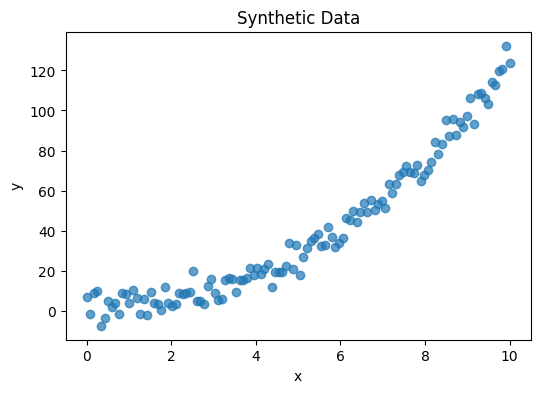

In [3]:
# Visualize the raw data
plt.figure(figsize=(6, 4))
plt.scatter(df["x"], df["y"], alpha=0.7)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Synthetic Data")
plt.show()

In [4]:
# Train-test split
X = df[["x"]]
y = df["y"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [5]:
# Polynomial regression pipeline
degree = 2
model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("lin_reg", LinearRegression()),
    ]
)

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('poly', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",False
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'


In [6]:
# Predictions and metrics
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 3.597677078990708
MSE: 20.006754367420083
RMSE: 4.472891052487204
R2: 0.9818456818046422


/home/yashwanth-aravind/ml-course/python-bootcamp/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


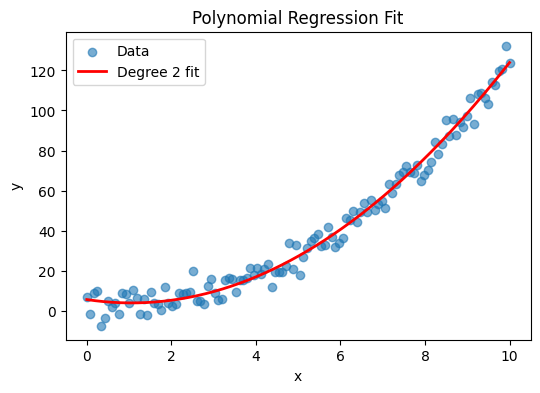

In [7]:
# Plot best-fit polynomial curve
x_grid = np.linspace(df["x"].min(), df["x"].max(), 200).reshape(-1, 1)
y_grid_pred = model.predict(x_grid)

plt.figure(figsize=(6, 4))
plt.scatter(df["x"], df["y"], alpha=0.6, label="Data")
plt.plot(x_grid, y_grid_pred, color="red", linewidth=2, label=f"Degree {degree} fit")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Polynomial Regression Fit")
plt.legend()
plt.show()

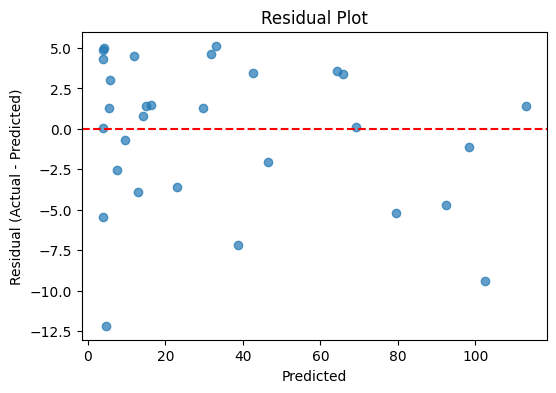

In [8]:
# Residual plot (error visualization)
residuals = y_test - y_pred

plt.figure(figsize=(6, 4))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot")
plt.show()

### From-scratch: manual polynomial features + normal equation

Polynomial regression is linear regression on engineered features. We build the
feature matrix $[1, x, x^2]$ by hand (no `PolynomialFeatures`) and solve it with the
same normal equation $\hat\beta = (X^TX)^{-1}X^Ty$ derived in
`02-linear-regression/notes.md`, to show it is literally the same algorithm.

In [9]:
def polynomial_features_manual(x, degree):
    """Build [1, x, x^2, ..., x^degree] by hand (equivalent to np.vander with increasing=True)."""
    x = np.asarray(x).reshape(-1)
    return np.column_stack([x ** p for p in range(0, degree + 1)])

degree_manual = 2
X_train_manual = polynomial_features_manual(X_train["x"].values, degree_manual)
X_test_manual = polynomial_features_manual(X_test["x"].values, degree_manual)

# Closed-form normal equation solved directly in NumPy
theta_manual = np.linalg.inv(X_train_manual.T @ X_train_manual) @ X_train_manual.T @ y_train.values
print("Manual normal-equation coefficients [1, x, x^2]:", theta_manual)

y_pred_manual = X_test_manual @ theta_manual
mse_manual = mean_squared_error(y_test, y_pred_manual)
print("Manual from-scratch test MSE:", mse_manual)
print("sklearn Pipeline test MSE (degree=2, from the cell above):", mse)

Manual normal-equation coefficients [1, x, x^2]: [ 5.53060277 -3.17840094  1.50201344]
Manual from-scratch test MSE: 20.006754367421077
sklearn Pipeline test MSE (degree=2, from the cell above): 20.006754367420083


### Experiment: degree sweep (underfit -> good fit -> overfit)

**Hypothesis (stated before running):** as polynomial degree increases on this
synthetic quadratic dataset, training error should decrease (or stay flat)
monotonically, while test error should be high at degree 1 (underfitting a curved
relationship with a straight line), reach a minimum near degree 2-3 (matching the
true quadratic generating process), and rise again at high degrees (overfitting —
the model starts fitting noise). This is the same bias-variance shape derived in
[`05b-bias-variance-tradeoff/notes.md`](../05b-bias-variance-tradeoff/notes.md);
here we run the concrete sweep on this topic's actual synthetic dataset rather than
re-deriving the theory.

In [10]:
degrees = [1, 2, 3, 4, 5, 8, 12, 16]
train_errors, test_errors = [], []

for d in degrees:
    pipe = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("poly", PolynomialFeatures(degree=d, include_bias=False)),
            ("lin_reg", LinearRegression()),
        ]
    )
    pipe.fit(X_train, y_train)
    train_errors.append(mean_squared_error(y_train, pipe.predict(X_train)))
    test_errors.append(mean_squared_error(y_test, pipe.predict(X_test)))

for d, tr, te in zip(degrees, train_errors, test_errors):
    print(f"degree={d:>2}  train_mse={tr:9.2f}  test_mse={te:9.2f}")

degree= 1  train_mse=   151.59  test_mse=   128.83
degree= 2  train_mse=    22.23  test_mse=    20.01
degree= 3  train_mse=    21.45  test_mse=    19.89
degree= 4  train_mse=    21.42  test_mse=    19.82
degree= 5  train_mse=    21.42  test_mse=    19.87
degree= 8  train_mse=    21.36  test_mse=    19.78
degree=12  train_mse=    20.47  test_mse=    27.34
degree=16  train_mse=    17.89  test_mse=    77.84


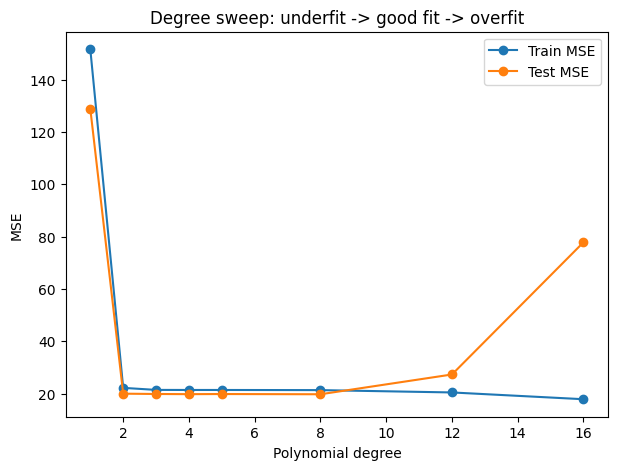

Degree with lowest test MSE: 8


In [11]:
plt.figure(figsize=(7, 5))
plt.plot(degrees, train_errors, marker="o", label="Train MSE")
plt.plot(degrees, test_errors, marker="o", label="Test MSE")
plt.xlabel("Polynomial degree")
plt.ylabel("MSE")
plt.title("Degree sweep: underfit -> good fit -> overfit")
plt.legend()
plt.show()

best_degree = degrees[int(np.argmin(test_errors))]
print("Degree with lowest test MSE:", best_degree)

**Actual result:** see the printed table and plot above for the concrete numbers
from this run — the executed values are the source of truth, not this static text.

**Interpretation:** if the minimum falls near degree 2 (the true generating
degree, `1.5*x**2 - 3*x + 5`), that confirms the model needs at least quadratic
capacity, and additional degrees beyond that mostly add variance without
reducing bias further.

**Limitations:** this sweep uses a single synthetic dataset and a single train/test
split (`random_state=42`); the exact best degree can shift with a different split
or noise draw. A production degree choice should use cross-validation, not one
held-out split, to avoid picking a degree that just happens to fit this particular
test set well.